# Equilibrium SYK and antisymmetric engineered-kernel analysis

This notebook keeps the original equilibrium analysis and replaces the engineered-kernel Schwarzian fit by the central odd-in-$\lambda$ response
\[
\frac{G_{+\lambda}(0,t)-G_{-\lambda}(0,t)}{2|\lambda|\,G_c(0,t)}.
\]
The convention used below is $G(0,t)=G_{\rm eq}(-t)$ for $t>0$.


In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import mpmath as mp


## Choices

In [2]:
root = Path("/Users/meabh/Desktop/CC Quench States/SYK Quenches/syk_sims").expanduser()
eq_root = root / "eq_runs"
J4_keep = 1.0

# Equilibrium plots
beta_keep_eq = [12, 15, 18, 20, 24,25, 30]

# Engineered-kernel plots
beta_keep_kernel = [12, 18, 24]
lambda_keep = [0.005]
delta_keep = [-0.021, -0.03, -0.044, -0.054]
cutoff_keep = [0.4, 0.5, 0.65, 0.75]

# UV timescale below which short-time transients (~Jt for ordinary
# equilibrium, ~t/Lambda for the engineered kernel) dominate over the
# t/beta conformal scaling
T_PLOT_MIN_EQ_COEFF = 2.0
T_PLOT_MIN_KERNEL_COEFF = 20.0

# Fit-window lower bound: "absolute" reuses same physical UV cut
# ; "relative" fixes x_fit_min = 1/(2*pi) regardless of J/Lambda.
FIT_WINDOW_MODE = "absolute"
X_FIT_MIN_RELATIVE = 1 / (2 * np.pi)

x_plot_max = 5.0
h2_fit_x_max = 5.0

Delta = 1 / 4
alpha0_original = 0.2648

## Load all equilibrium files

In [3]:
def decode_number(value):
    s = str(value)
    s = s.replace("em", "e-").replace("ep", "e+")
    if s.startswith("m"):
        s = "-" + s[1:]
    return float(s.replace("p", "."))


def folder_value(folder, tag, default=np.nan):
    match = re.search(rf"(?:^|_){re.escape(tag)}_([^_]+)", folder)
    return decode_number(match.group(1)) if match else default


rows = []

for filename in sorted(eq_root.glob("**/*.npz")):
    try:
        with np.load(filename, allow_pickle=True) as data:
            if not {"tau_grid", "Ggt_tau"}.issubset(data.files):
                continue

            if "metadata_json" in data.files:
                raw = np.asarray(data["metadata_json"]).item()
                if isinstance(raw, bytes):
                    raw = raw.decode()
                meta = json.loads(str(raw))
            else:
                meta = {}

        folder = filename.parent.name

        lam = meta.get("kernel_lambda", folder_value(folder, "lam"))
        delta_value = meta.get("kernel_c", folder_value(folder, "c"))
        cutoff = meta.get("kernel_cutoff", folder_value(folder, "L"))

        is_kernel = (
            "_lam_" in folder
            or np.isfinite(float(lam))
            or np.isfinite(float(delta_value))
            or np.isfinite(float(cutoff))
        )

        rows.append({
            "filename": str(filename),
            "folder": folder,
            "is_kernel": is_kernel,
            "J2": float(meta.get("J2", 0.0)),
            "J4": float(meta.get("J4", folder_value(folder, "J4"))),
            "beta": float(meta.get("beta", folder_value(folder, "b"))),
            "mu": float(meta.get("mu", meta.get("chemical_potential", folder_value(folder, "mu", 0.0)))),
            "kernel_lambda": float(lam) if np.isfinite(float(lam)) else 0.0,
            "kernel_delta": float(delta_value) if np.isfinite(float(delta_value)) else 0.0,
            "kernel_cutoff": float(cutoff) if np.isfinite(float(cutoff)) else np.nan,
            "dt": float(meta.get("dt", folder_value(folder, "dt"))),
            "omega_max": float(meta.get("omega_max", folder_value(folder, "om"))),
            "Nw": int(meta.get("Nw", folder_value(folder, "Nw", -1))),
            "tol": float(meta.get("tol", np.nan)),
        })

    except Exception as exc:
        print(f"Skipping {filename}: {exc}")


df_all_eq = pd.DataFrame(rows)

df_eq_all = (
    df_all_eq[~df_all_eq["is_kernel"]]
    .sort_values(["J4", "beta", "mu", "dt", "Nw", "omega_max"])
    .reset_index(drop=True)
)

df_kernel_all = (
    df_all_eq[df_all_eq["is_kernel"]]
    .sort_values([
        "J4", "beta", "mu", "kernel_lambda", "kernel_delta",
        "kernel_cutoff", "dt", "Nw", "omega_max"
    ])
    .reset_index(drop=True)
)

print("Original equilibrium files:", len(df_eq_all))
print("Engineered-kernel files:", len(df_kernel_all))

Skipping /Users/meabh/Desktop/CC Quench States/SYK Quenches/syk_sims/eq_runs/eq_J4_1_b_12_lam_m0p005_c_0p72_L_4p0_dt_0p0016_om_36_Nw_8641 (1)/syk_eq_J2_0_J4_1_beta_12_klam_m0p005_kc_0p72_kcut_4_dt_0p0016_om_36_Nw_8641_tol_1em08_c52a082f.npz: could not convert string to float: '8641 (1)'
Skipping /Users/meabh/Desktop/CC Quench States/SYK Quenches/syk_sims/eq_runs/eq_J4_1_b_12_lam_m0p005_c_0p72_L_4p0_dt_0p0016_om_36_Nw_8641 (2)/syk_eq_J2_0_J4_1_beta_12_klam_m0p005_kc_0p72_kcut_4_dt_0p0016_om_36_Nw_8641_tol_1em08_c52a082f.npz: could not convert string to float: '8641 (2)'
Skipping /Users/meabh/Desktop/CC Quench States/SYK Quenches/syk_sims/eq_runs/eq_J4_1_b_12_lam_m0p005_c_0p72_L_4p0_dt_0p0016_om_36_Nw_8641 (3)/syk_eq_J2_0_J4_1_beta_12_klam_m0p005_kc_0p72_kcut_4_dt_0p0016_om_36_Nw_8641_tol_1em08_c52a082f.npz: could not convert string to float: '8641 (3)'
Skipping /Users/meabh/Desktop/CC Quench States/SYK Quenches/syk_sims/eq_runs/eq_J4_1_b_12_lam_m0p005_c_0p72_L_4p0_dt_0p0016_om_36_Nw_864

Original equilibrium files: 390
Engineered-kernel files: 484


## Keep the best numerical resolution for each physical parameter set

In [4]:
# Ranking requested here:
#     smallest dt, then largest Nw, then largest omega_max.
# tol is only a final tie-breaker.

eq_keys = ["J2", "J4", "beta", "mu"]
kernel_keys = [
    "J2", "J4", "beta", "mu",
    "kernel_lambda", "kernel_delta", "kernel_cutoff",
]

df_eq_best = (
    df_eq_all
    .sort_values(
        eq_keys + ["dt", "Nw", "omega_max", "tol"],
        ascending=[True] * len(eq_keys) + [True, False, False, True],
    )
    .drop_duplicates(eq_keys, keep="first")
    .reset_index(drop=True)
)

df_kernel_best = (
    df_kernel_all
    .sort_values(
        kernel_keys + ["dt", "Nw", "omega_max", "tol"],
        ascending=[True] * len(kernel_keys) + [True, False, False, True],
    )
    .drop_duplicates(kernel_keys, keep="first")
    .reset_index(drop=True)
)


def selected(values, keep):
    if keep is None:
        return np.ones(len(values), dtype=bool)
    return np.any(
        np.isclose(
            np.asarray(values, dtype=float)[:, None],
            np.asarray(keep, dtype=float)[None, :],
        ),
        axis=1,
    )


def selected_pairs(values_a, values_b, keep_a, keep_b):
    # Like selected(), but keep_a/keep_b are matched pairwise by index
    # (keep_a[i], keep_b[i]), not as an independent cartesian product --
    # e.g. delta_keep/cutoff_keep are meant as (delta, Lambda) pairs.
    if keep_a is None or keep_b is None:
        return np.ones(len(values_a), dtype=bool)
    values_a = np.asarray(values_a, dtype=float)
    values_b = np.asarray(values_b, dtype=float)
    mask = np.zeros(len(values_a), dtype=bool)
    for a, b in zip(keep_a, keep_b):
        mask |= np.isclose(values_a, a) & np.isclose(values_b, b)
    return mask


eq_mask = (
    np.isclose(df_eq_best["J4"], J4_keep)
    & np.isclose(df_eq_best["mu"], 0.0)
    & selected(df_eq_best["beta"], beta_keep_eq)
)

kernel_mask = (
    np.isclose(df_kernel_best["J4"], J4_keep)
    & np.isclose(df_kernel_best["mu"], 0.0)
    & selected(df_kernel_best["beta"], beta_keep_kernel)
    & selected(np.abs(df_kernel_best["kernel_lambda"]), lambda_keep)
    & selected_pairs(
        df_kernel_best["kernel_delta"], df_kernel_best["kernel_cutoff"],
        delta_keep, cutoff_keep,
    )
)

df_eq_plot = df_eq_best[eq_mask].copy()
df_kernel_plot = df_kernel_best[kernel_mask].copy()

## Small trace and theory helpers

In [5]:
def load_G0t(filename):
    with np.load(filename, allow_pickle=True) as data:
        tau = np.asarray(data["tau_grid"], dtype=float).squeeze()
        G = np.asarray(data["Ggt_tau"], dtype=complex).squeeze()

    keep = tau < 0
    t = -tau[keep]
    G = G[keep]

    order = np.argsort(t)
    return t[order], G[order]


def Gc_im_abs(t, beta, J):
    b = (1 / (4 * np.pi * J**2)) ** 0.25
    return (
        b
        * np.cos(np.pi / 4)
        * (np.pi / (beta * np.sinh(np.pi * t / beta))) ** 0.5
    )



def Gc_complex(t, beta, J):
    amplitude = (
        (0.5 - Delta)
        * np.tan(np.pi * Delta)
        / (np.pi * J**2)
    ) ** Delta

    envelope = amplitude * (
        np.pi / (beta * np.sinh(np.pi * t / beta))
    ) ** (2 * Delta)

    # G_c^>(-t), matching G(0,t)=G_eq(-t).
    return envelope * (
        np.sin(np.pi * Delta)
        - 1j * np.cos(np.pi * Delta)
    )


def phi_h2(x):
    # Here tanh^{-1} means coth = 1/tanh, matching the existing notebook.
    return (2 * np.pi * x + np.pi) / np.tanh(np.pi * x) - 2


def uv_t_plot_min(*, J=None, Lambda=None):
    # Ordinary equilibrium: pass J. Engineered kernel: pass Lambda.
    if Lambda is not None:
        return T_PLOT_MIN_KERNEL_COEFF / Lambda
    return T_PLOT_MIN_EQ_COEFF / J


def fit_x_min_for(x_plot_min_row):
    if FIT_WINDOW_MODE == "absolute":
        return x_plot_min_row
    if FIT_WINDOW_MODE == "relative":
        return X_FIT_MIN_RELATIVE
    raise ValueError(f"Unknown FIT_WINDOW_MODE: {FIT_WINDOW_MODE!r}")


# One colour family per Lambda; beta sets the shade within it 
_LAMBDA_CMAP_ZERO = "Greys"
_LAMBDA_CMAPS = ["Blues", "Oranges", "Greens", "Reds", "Purples"]


def _colour_for(Lambda, beta, lambdas, betas):
    nonzero = [L for L in lambdas if not np.isclose(L, 0.0)]
    if np.isclose(Lambda, 0.0):
        cmap = plt.colormaps[_LAMBDA_CMAP_ZERO]
    else:
        cmap = plt.colormaps[_LAMBDA_CMAPS[nonzero.index(Lambda) % len(_LAMBDA_CMAPS)]]
    beta_pos = betas.index(beta) / max(len(betas) - 1, 1)
    return cmap(0.35 + 0.55 * beta_pos)

### Real-time $h_1$ template

`phi_h2` above is the real-time continuation of the closed-form $f_0(u)=2+\pi(1-2u)\cot(\pi u)$
under $\tau\to-it$ (i.e. $u\to-ix$, $x=t/\beta$), combined as $\mathrm{Im}-\mathrm{Re}$:
$f_0(x)=\mathrm{Im}\,f_0(-ix)-\mathrm{Re}\,f_0(-ix)$. This is verified below to reproduce the
closed-form `phi_h2` to machine precision. The same recipe applied to the general conformal block
$f_h(u)$ (Eq. (20) of Arguello Cruz & Tarnopolsky, Phys. Rev. B **108**, 035103 (2023)) at
$h=h_1\approx3.7735$ gives the real-time $h_1$ template $f_1(x)$, used below to fit

$$
(\beta J)\,D_\lambda(x) = b_0\,f_0(x) + b_1\,\frac{f_1(x)}{(\beta J)^{h_1-2}},
$$

the real-time analogue of the Euclidean expansion
$G_*/G_c-1=-\alpha_0/(\beta J)f_0-\alpha_1/(\beta J)^{h_1-1}f_1-\cdots$ (Eq. (22) of the same paper).
With this normalization $b_0,b_1$ are directly comparable to $\alpha_0,\alpha_1$. The $f_{00}$ term
is dropped: its coefficient scales as $\alpha_0^2$, so whenever $b_0$ is tuned toward zero it is
doubly suppressed relative to the $h_1$ term kept here.


In [6]:
mp.mp.dps = 30
_DELTA_CFT = mp.mpf(1) / 4


def _k_of_h(h):
    return (
        mp.gamma(2 * _DELTA_CFT - h) * mp.gamma(h + 2 * _DELTA_CFT - 1)
        / (mp.gamma(2 * _DELTA_CFT - 2) * mp.gamma(2 * _DELTA_CFT + 1))
    ) * (1 - mp.sin(mp.pi * h) / mp.sin(2 * mp.pi * _DELTA_CFT))


H1 = float(mp.findroot(lambda h: _k_of_h(h) - 1, mp.mpf("3.77")))


def _general_f_h_complex(u, h):
    # Eq. (20) of Arguello Cruz & Tarnopolsky (2023), evaluated at complex u.
    theta = 2 * mp.pi * u
    z = mp.e ** (1j * theta)

    def A(zz):
        return (1 - zz) ** h * mp.hyp2f1(h, h, 1, zz)

    numerator = A(z) + A(mp.conj(z))
    value = (
        (2 * mp.pi) ** (h - 1) * mp.gamma(h) ** 2 * numerator
        / (2 * mp.sin(mp.pi * h / 2) * mp.gamma(2 * h - 1))
    )
    return complex(value)


_phi_x_grid = np.linspace(0.02, 8.0, 800)
_phi_h1_table = np.array(
    [_general_f_h_complex(-1j * xx, H1) for xx in _phi_x_grid]
)
_phi_h1_table = _phi_h1_table.imag - _phi_h1_table.real


def phi_h1(x):
    return np.interp(np.asarray(x, dtype=float), _phi_x_grid, _phi_h1_table)


def phi_h1_scaled(x, betaJ):
    return phi_h1(x) / betaJ ** (H1 - 2.0)


# Sanity check of Im-Re(-ix) against closed form (h=2 exactly)
_xcheck = np.linspace(0.1, 4.0, 25)
_ucheck = -1j * _xcheck
_f0check = 2 + np.pi * (1 - 2 * _ucheck) / np.tan(np.pi * _ucheck)
_phi2check = _f0check.imag - _f0check.real

print(f"h1 = {H1:.10f}  (paper quotes ~3.7735)")
print(
    "phi_h2 cross-check, max|Im-Re(-ix) recipe - closed form| =",
    np.max(np.abs(_phi2check - phi_h2(_xcheck))),
)


h1 = 3.7735356186  (paper quotes ~3.7735)
phi_h2 cross-check, max|Im-Re(-ix) recipe - closed form| = 1.0658141036401503e-14


## 1. Original equilibrium data: $|\mathrm{Im}\,G(0,t)|$

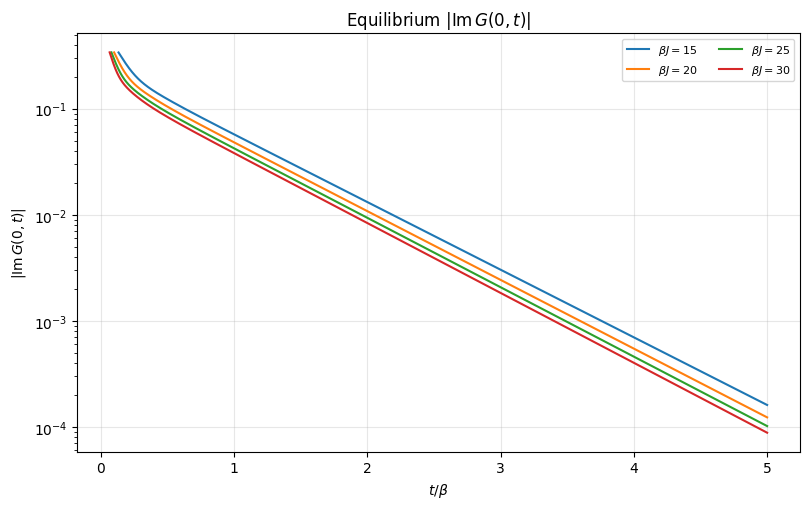

In [7]:
fig, ax = plt.subplots(figsize=(8.2, 5.2))

for _, row in df_eq_plot.sort_values("beta").iterrows():
    t, G = load_G0t(row["filename"])
    beta = float(row["beta"])
    J = float(row["J4"])
    x_min_row = uv_t_plot_min(J=J) / beta

    keep = (
        (t > 0)
        & (t / beta >= x_min_row)
        & (t / beta <= x_plot_max)
    )

    ax.plot(
        t[keep] / beta,
        np.abs(np.imag(G[keep])),
        lw=1.5,
        label=rf"$\beta J={beta * row['J4']:g}$",
    )

ax.set_xlabel(r"$t/\beta$")
ax.set_ylabel(r"$|\operatorname{Im}G(0,t)|$")
ax.set_title(r"Equilibrium $|\operatorname{Im}G(0,t)|$")
ax.grid(alpha=0.3)
ax.set_yscale('log')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

### Original equilibrium correction and the $h=2$ template

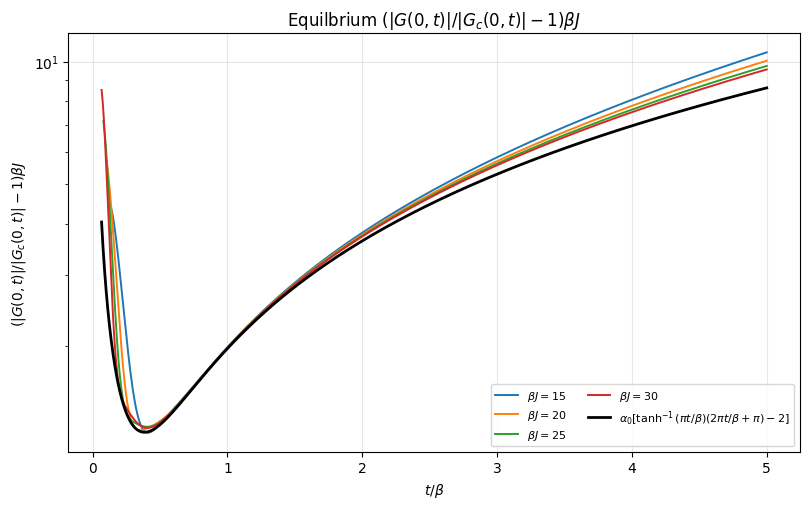

In [8]:
fig, ax = plt.subplots(figsize=(8.2, 5.2))

x_theory_min = uv_t_plot_min(J=J4_keep) / df_eq_plot["beta"].max()

for _, row in df_eq_plot.sort_values("beta").iterrows():
    J = float(row["J4"])
    beta = float(row["beta"])
    t, G = load_G0t(row["filename"])

    x = t / beta
    x_min_row = uv_t_plot_min(J=J) / beta
    ratio = np.abs(np.imag(G)) / Gc_im_abs(t, beta, J)
    correction = (ratio - 1) * beta * J

    keep = (
        np.isfinite(correction)
        & (correction > 0)
        & (x >= x_min_row)
        & (x <= x_plot_max)
    )

    ax.plot(
        x[keep],
        correction[keep],
        lw=1.4,
        label=rf"$\beta J={beta * J:g}$",
    )

x_theory = np.logspace(
    np.log10(x_theory_min),
    np.log10(x_plot_max),
    500,
)

ax.plot(
    x_theory,
    alpha0_original * phi_h2(x_theory),
    color="black",
    lw=2,
    label=(
        r"$\alpha_0[\tanh^{-1}(\pi t/\beta)"
        r"(2\pi t/\beta+\pi)-2]$"
    ),
)

#ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$t/\beta$")
ax.set_ylabel(r"$(|G(0,t)|/|G_c(0,t)|-1)\beta J$")
ax.set_title(r"Equilbrium $(|G(0,t)|/|G_c(0,t)|-1)\beta J$")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

### Fit the ordinary-equilibrium $h=2$ amplitude

In [9]:
ordinary_h2_rows = []

for _, row in df_eq_plot.sort_values("beta").iterrows():
    J = float(row["J4"])
    beta = float(row["beta"])
    t, G = load_G0t(row["filename"])

    x = t / beta
    correction = (
        np.abs(np.imag(G)) / Gc_im_abs(t, beta, J) - 1
    ) * beta * J

    x_min_row = uv_t_plot_min(J=J) / beta
    fit_lo = fit_x_min_for(x_min_row)

    fit = (
        np.isfinite(correction)
        & (x >= fit_lo)
        & (x <= h2_fit_x_max)
    )

    phi = phi_h2(x[fit])
    amplitude = np.dot(phi, correction[fit]) / np.dot(phi, phi)

    ordinary_h2_rows.append({
        "beta": beta,
        "betaJ": beta * J,
        "mu": float(row["mu"]),
        "h2_amplitude": amplitude,
        "filename": row["filename"],
    })

df_h2_ordinary = pd.DataFrame(ordinary_h2_rows)
display(df_h2_ordinary)

,beta,betaJ,mu,h2_amplitude,filename
0,15.0,15.0,0.0,0.303487,/Users/meabh/Desktop/CC Quench States/SYK Quen...
1,20.0,20.0,0.0,0.294236,/Users/meabh/Desktop/CC Quench States/SYK Quen...
2,25.0,25.0,0.0,0.288743,/Users/meabh/Desktop/CC Quench States/SYK Quen...
3,30.0,30.0,0.0,0.285136,/Users/meabh/Desktop/CC Quench States/SYK Quen...


### Plot after subtracting the leading $h=2$ contribution

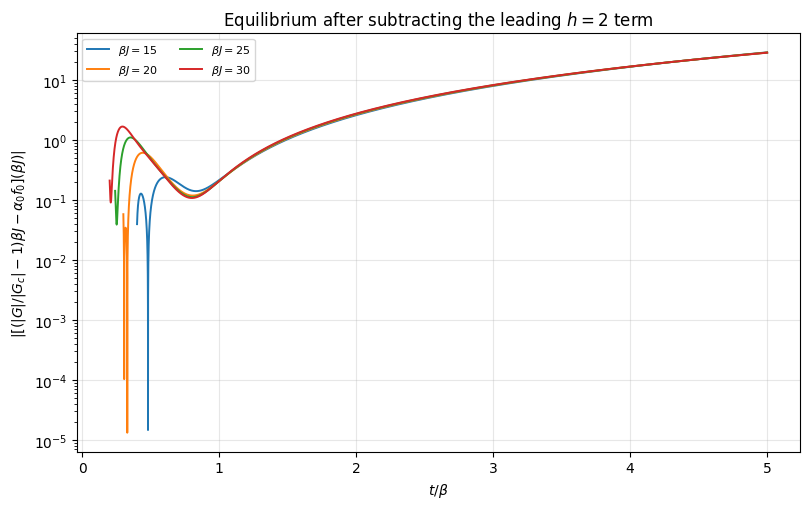

In [10]:
fig, ax = plt.subplots(figsize=(8.2, 5.2))

for _, row in df_eq_plot.sort_values("beta").iterrows():
    J = float(row["J4"])
    beta = float(row["beta"])
    t, G = load_G0t(row["filename"])

    x = t / beta
    x_min_row = 3*uv_t_plot_min(J=J) / beta
    ratio = np.abs(np.imag(G)) / Gc_im_abs(t, beta, J)

    leading = alpha0_original * phi_h2(x)
    residual = ((ratio - 1) * beta * J - leading) * beta * J

    keep = (
        np.isfinite(residual)
        & (np.abs(residual) > 0)
        & (x >= x_min_row)
        & (x <= x_plot_max)
    )

    ax.plot(
        x[keep],
        np.abs(residual[keep]),
        lw=1.4,
        label=rf"$\beta J={beta * J:g}$",
    )

#ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$t/\beta$")
ax.set_ylabel(
    r"$|[(|G|/|G_c|-1)\beta J-\alpha_0 f_0](\beta J)|$"
)
ax.set_title(r"Equilibrium after subtracting the leading $h=2$ term")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## 3. Engineered-kernel equilibrium curves and odd-in-$\lambda$ response


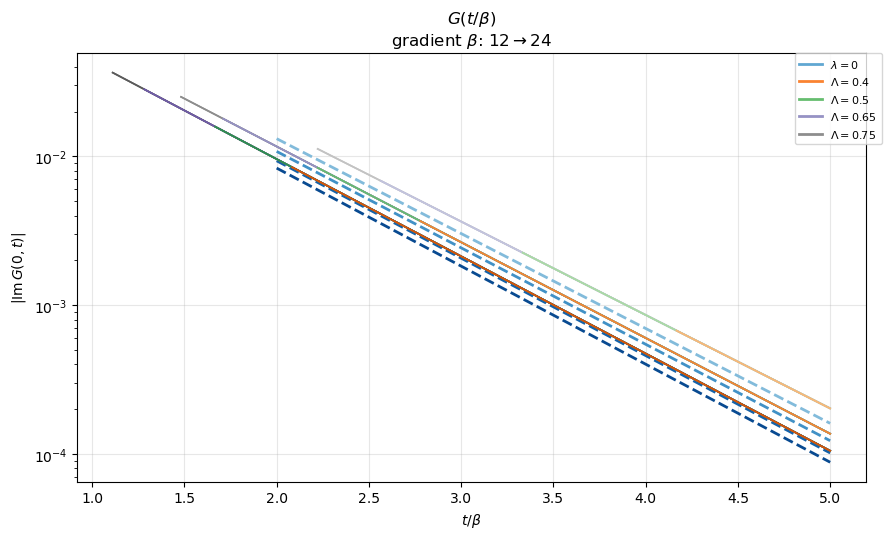

In [143]:
fig, ax = plt.subplots(figsize=(9, 5.5))

lambdas = sorted({0.0} | set(df_kernel_plot["kernel_cutoff"].unique()))
betas = sorted(set(df_eq_plot["beta"].unique()) | set(df_kernel_plot["beta"].unique()))

for _, row in df_eq_plot.sort_values("beta").iterrows():
    t, G = load_G0t(row["filename"])
    beta = row["beta"]
    x = t / beta
    keep = (x >= 2) & (x <= x_plot_max)

    ax.plot(
        x[keep], np.abs(np.imag(G[keep])), "--", lw=2,
        color=_colour_for(0.0, beta, lambdas, betas),
    )

for _, row in df_kernel_plot.sort_values(
    ["kernel_lambda", "kernel_delta", "beta"]
).iterrows():
    t, G = load_G0t(row["filename"])
    beta = row["beta"]
    x = t / beta
    x_min_row = uv_t_plot_min(Lambda=row["kernel_cutoff"]) / beta
    keep = (x >= x_min_row) & (x <= x_plot_max)

    ax.plot(
        x[keep], np.abs(np.imag(G[keep])), lw=1.2,
        color=_colour_for(row["kernel_cutoff"], beta, lambdas, betas),
    )

handles = [
    Line2D(
        [0], [0], color=_colour_for(L, betas[2], lambdas, betas), lw=2,
        label=(r"$\lambda=0$" if np.isclose(L, 0.0) else rf"$\Lambda={L:g}$"),
    )
    for L in lambdas
]

ax.set_xlabel(r"$t/\beta$")
ax.set_ylabel(r"$|\operatorname{Im}G(0,t)|$")
ax.set_title(r"$G(t/\beta)$"+"\n" + r"gradient $\beta$: " + f"{beta_keep_kernel[0]:1g}"+r"$\to$" +f"{beta_keep_kernel[-1]:1g}")
ax.set_yscale('log')
ax.grid(alpha=0.3)
ax.legend(handles=handles, loc="upper right", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0, fontsize=8)
fig.tight_layout()
plt.show()


### Fit function: pair $\pm\lambda$ runs and jointly fit $b_0,b_1$

Builds $(\beta J)D_\lambda(x)$ for every retained $(\beta,\delta,\Lambda)$ and fits it to the
two-template model $b_0\,f_0(x)+b_1\,f_1(x)/(\beta J)^{h_1-2}$ by linear least squares
(complex: the fit tracks both the real amplitude and the small "quadrature" component, as the
original single-template fit did).


In [139]:
def build_kernel_odd_response(
    *, beta_keep, lambda_keep, delta_keep, cutoff_keep,
    fit_x_max=h2_fit_x_max, plot=True, show_fit_overlay=True, beta_rescale=True,
):
    pair_source = df_kernel_all.copy()
    pair_source["abs_lambda"] = np.abs(pair_source["kernel_lambda"])
    pair_source["lambda_sign"] = np.sign(pair_source["kernel_lambda"])

    mask = (
        np.isclose(pair_source["J4"], J4_keep)
        & np.isclose(pair_source["mu"], 0.0)
        & (pair_source["abs_lambda"] > 0)
        & selected(pair_source["beta"], beta_keep)
        & selected(pair_source["abs_lambda"], lambda_keep)
        & selected_pairs(
            pair_source["kernel_delta"], pair_source["kernel_cutoff"],
            delta_keep, cutoff_keep,
        )
    )
    pair_source = pair_source[mask]

    physical_keys = [
        "J2", "J4", "beta", "mu", "abs_lambda", "kernel_delta", "kernel_cutoff",
    ]
    resolution_keys = ["dt", "Nw", "omega_max"]

    plus = pair_source[pair_source["lambda_sign"] > 0]
    minus = pair_source[pair_source["lambda_sign"] < 0]
    pairs = (
        plus.merge(minus, on=physical_keys + resolution_keys, suffixes=("_plus", "_minus"))
        .sort_values(
            physical_keys + resolution_keys,
            ascending=[True] * len(physical_keys) + [True, False, False],
        )
        .drop_duplicates(physical_keys)
        .reset_index(drop=True)
    )
    if pairs.empty:
        raise RuntimeError("No +/- lambda pairs match the requested filters.")

    lambdas = sorted(pairs["kernel_cutoff"].unique())
    betas = sorted(pairs["beta"].unique())

    rows = []
    fig, ax = (plt.subplots(figsize=(9, 5.5)) if plot else (None, None))

    for _, row in pairs.iterrows():
        J, beta, lam = float(row["J4"]), float(row["beta"]), float(row["abs_lambda"])
        Lambda, betaJ = float(row["kernel_cutoff"]), beta * J

        t, G_plus = load_G0t(row["filename_plus"])
        t_minus, G_minus = load_G0t(row["filename_minus"])
        assert np.allclose(t, t_minus)

        x = t / beta
        D_odd = (G_plus - G_minus) / (2 * lam * Gc_complex(t, beta, J))
        scaled = D_odd * betaJ  # (beta J) D_lambda(x)

        x_min_row = uv_t_plot_min(Lambda=Lambda) / beta
        fit = (
            np.isfinite(np.real(scaled)) & np.isfinite(np.imag(scaled))
            & (x >= fit_x_min_for(x_min_row)) & (x <= fit_x_max)
        )
        basis = np.column_stack(
            [phi_h2(x[fit]), phi_h1_scaled(x[fit], betaJ)]
        ).astype(complex)
        coef, *_ = np.linalg.lstsq(basis, scaled[fit], rcond=None)
        b0, b1 = coef

        residual_rms = float(np.sqrt(np.mean(np.abs(scaled[fit] - basis @ coef) ** 2)))
        data_rms = float(np.sqrt(np.mean(np.abs(scaled[fit]) ** 2)))
        relative_residual = residual_rms / data_rms if data_rms > 0 else np.nan

        keep = np.isfinite(np.real(scaled)) & (x >= x_min_row) & (x <= x_plot_max)

        if plot:
            colour = _colour_for(Lambda, beta, lambdas, betas)
            if beta_rescale==True:
                ax.plot(x[keep], np.abs(scaled[keep]), lw=1.3, color=colour)
                if show_fit_overlay:
                    model = b0 * phi_h2(x[keep]) + b1 * phi_h1_scaled(x[keep], betaJ)
                    ax.plot(x[keep], np.abs(model), "--", lw=1.0, color=colour)
            else:
                ax.plot(x[keep], np.abs(scaled[keep])/beta, lw=1.3, color=colour)
                if show_fit_overlay:
                    model = b0 * phi_h2(x[keep]) + b1 * phi_h1_scaled(x[keep], betaJ)
                    ax.plot(x[keep], np.abs(model)/beta, "--", lw=1.0, color=colour)

        rows.append({
            "J4": J, "beta": beta, "betaJ": betaJ, "mu": float(row["mu"]),
            "abs_lambda": lam, "kernel_delta": float(row["kernel_delta"]),
            "kernel_cutoff": Lambda,
            "dt": float(row["dt"]), "Nw": int(row["Nw"]), "omega_max": float(row["omega_max"]),
            "x": x[keep], "scaled_response": scaled[keep],
            "h2_amplitude": float(b0.real), "h2_quadrature": float(b0.imag),
            "h1_amplitude": float(b1.real), "h1_quadrature": float(b1.imag),
            "fit_residual_rms": residual_rms, "fit_relative_residual": relative_residual,
            "filename_plus": row["filename_plus"], "filename_minus": row["filename_minus"],
        })

    df_odd = pd.DataFrame(rows)

    if plot:
        handles = [
            Line2D([0], [0], color=_colour_for(Lambda, betas[1], lambdas, betas),
                   lw=2, label=rf"$\Lambda={Lambda:g}$")
            for Lambda in lambdas
        ]
        ax.set_xlabel(r"$t/\beta$")
        if beta_rescale==True:
            ax.set_ylabel(r"$\beta J|D_\lambda|$")
            ax.set_title(
                r"$\beta J |G_*(t/\beta)_\lambda-G_*(t/\beta)_{-\lambda}|/2\lambda G_c(t/\beta)$" +
                "\n" + r"gradient $\beta$: " + f"{beta_keep_kernel[0]:1g}"+r"$\to$" +f"{beta_keep_kernel[-1]:1g}"
            )
        else:
            ax.set_ylabel(r"$|D_\lambda|$")
            ax.set_title(
                r"$ |G_*(t/\beta)_\lambda-G_*(t/\beta)_{-\lambda}|/2\lambda G_c(t/\beta)$" +
                "\n" + r"gradient $\beta$: " + f"{beta_keep_kernel[0]:1g}"+r"$\to$" +f"{beta_keep_kernel[-1]:1g}"
            )
        ax.grid(alpha=0.3)
        ax.set_yscale('log')
        ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.07, 1.0),
                   borderaxespad=0.0, fontsize=8)
        plt.show()

    return df_odd


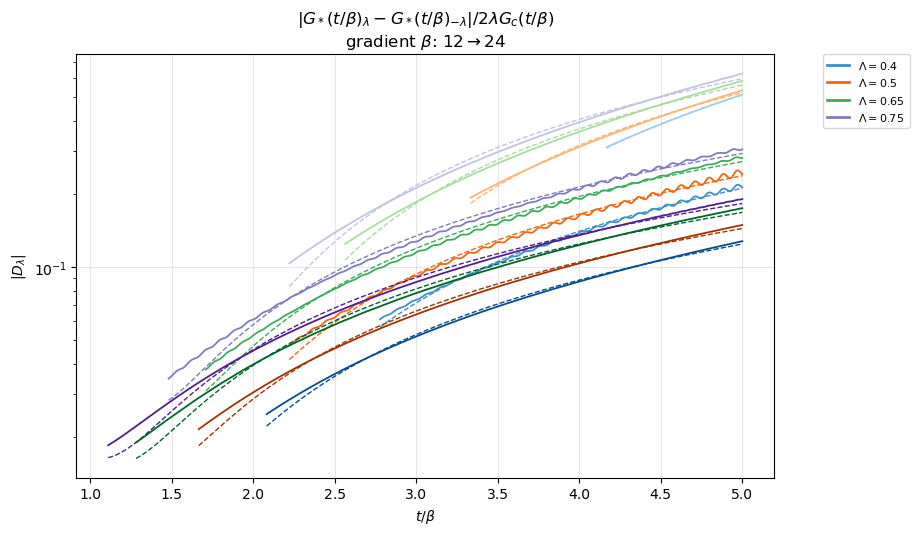

,beta,betaJ,kernel_delta,kernel_cutoff,h2_amplitude,h1_amplitude,fit_relative_residual
3,12.0,12.0,-0.021,0.40,1.761222,28.353462,0.003614
7,18.0,18.0,-0.021,0.40,0.493800,18.221422,0.021881
11,24.0,24.0,-0.021,0.40,0.236731,16.322885,0.019793
2,12.0,12.0,-0.030,0.50,1.227209,20.644800,0.013664
6,18.0,18.0,-0.030,0.50,0.410516,16.163453,0.032249
10,24.0,24.0,-0.030,0.50,0.207655,15.593065,0.025470
1,12.0,12.0,-0.044,0.65,0.908278,16.204250,0.027683
5,18.0,18.0,-0.044,0.65,0.341283,14.653765,0.034196
9,24.0,24.0,-0.044,0.65,0.179258,15.044276,0.031367
0,12.0,12.0,-0.054,0.75,0.803582,14.863084,0.035065


In [140]:
df_kernel_odd = build_kernel_odd_response(
    beta_keep=beta_keep_kernel,
    lambda_keep=lambda_keep,
    delta_keep=delta_keep,
    cutoff_keep=cutoff_keep,
    beta_rescale=False
)

display(df_kernel_odd[[
    "beta", "betaJ", "kernel_delta", "kernel_cutoff",
    "h2_amplitude", "h1_amplitude", "fit_relative_residual",
]].sort_values(["kernel_cutoff", "kernel_delta", "beta"]))


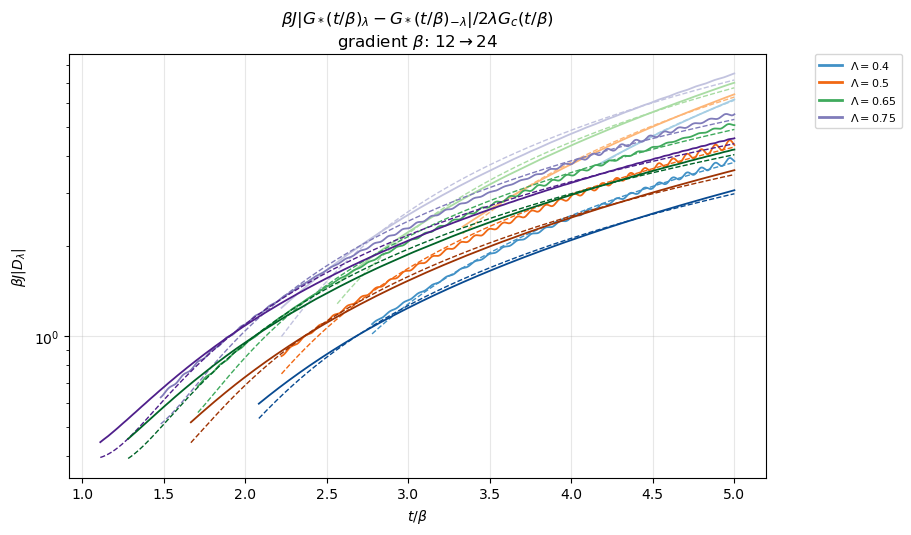

In [141]:
df_kernel_odd = build_kernel_odd_response(
    beta_keep=beta_keep_kernel,
    lambda_keep=lambda_keep,
    delta_keep=delta_keep,
    cutoff_keep=cutoff_keep,
)

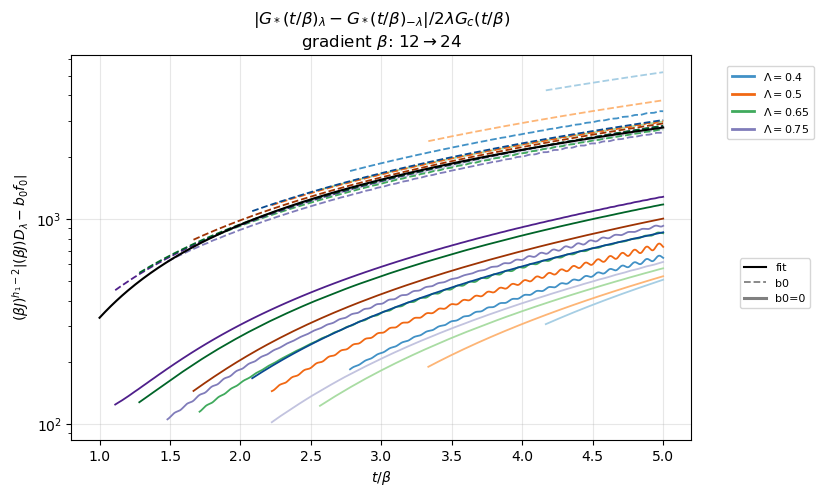

In [142]:
# Rescaled by (beta J)^(h1-2) so that -- if the fit is good -- what's left
# is ~ b1*f_1(t/beta). Thick = raw (b0 not subtracted); dashed = with
# b0*f_0 subtracted; black = fit reference b1*f_1(x).

fig, ax = plt.subplots(figsize=(8, 5))

lambdas = sorted(df_kernel_odd["kernel_cutoff"].unique())
betas = sorted(df_kernel_odd["beta"].unique())

for _, row in df_kernel_odd.iterrows():
    x = np.asarray(row["x"])
    scaled = np.asarray(row["scaled_response"])
    betaJ = row["betaJ"]
    colour = _colour_for(row["kernel_cutoff"], row["beta"], lambdas, betas)

    h2_term = (row["h2_amplitude"] + 1j * row["h2_quadrature"]) * phi_h2(x)

    raw = betaJ ** (H1 - 2.0) * scaled
    subtracted = betaJ ** (H1 - 2.0) * (scaled - h2_term)

    ax.plot(x, np.abs(raw), lw=1.3, color=colour)
    ax.plot(x, np.abs(subtracted), lw=1.3, linestyle="--", color=colour)

# Reference fit curve b1*f_1(x), using the largest-(beta J) row available.
ref_row = df_kernel_odd.loc[df_kernel_odd["betaJ"].idxmax()]
b1_ref = ref_row["h1_amplitude"] + 1j * ref_row["h1_quadrature"]
x_ref = np.linspace(1, 5, 300)
ax.plot(x_ref, np.abs(b1_ref * phi_h1(x_ref)), lw=1.5, color="black")

lambda_handles = [
    Line2D([0], [0], color=_colour_for(L, betas[1], lambdas, betas), lw=2,
           label=rf"$\Lambda={L:g}$")
    for L in lambdas
]
style_handles = [
    Line2D([0], [0], color="black", lw=1.5, label="fit"),
    Line2D([0], [0], color="grey", lw=1.3, linestyle="--", label="b0"),
    Line2D([0], [0], color="grey", lw=2.2, label="b0=0"),
]

ax.set_xlabel(r"$t/\beta$")
ax.set_ylabel(r"$(\beta J)^{h_1-2}\left|(\beta J)D_\lambda-b_0 f_0\right|$")
ax.set_title(
    r"$|G_*(t/\beta)_\lambda-G_*(t/\beta)_{-\lambda}|/2\lambda G_c(t/\beta)$"
    "\n" + r"gradient $\beta$: " + f"{beta_keep_kernel[0]:1g}"+r"$\to$" +f"{beta_keep_kernel[-1]:1g}"
)
ax.set_yscale("log")
ax.grid(alpha=0.3)
legend1 = ax.legend(
    handles=lambda_handles, loc="upper left",
    bbox_to_anchor=(1.04, 1.0), borderaxespad=1.0, fontsize=8,
)
ax.add_artist(legend1)
ax.legend(
    handles=style_handles, loc="upper left",
    bbox_to_anchor=(1.06, 0.5), borderaxespad=1.0, fontsize=8,
)

plt.show()
